2026-09-16 12:41:27.377 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 1, remaining_step: 9
2026-09-16 12:41:27.379 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 2, remaining_step: 8
2026-09-16 12:41:27.380 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 3, remaining_step: 7
2026-09-16 12:41:27.380 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 4, remaining_step: 6
2026-09-16 12:41:27.381 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 5, remaining_step: 5
2026-09-16 12:41:27.381 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 6, remaining_step: 4
2026-09-16 12:41:27.382 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 7, remaining_step: 3
2026-09-16 12:41:27.382 | INFO     | __main__:loop_node:14 - loop_node, cur_step: 8, remaining_step: 2
2026-09-16 12:41:27.383 | INFO     | __main__:router:19 - 当前可用超步：2，已不足2步，终止运行图


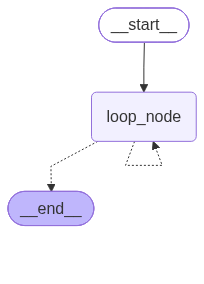

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.managed import RemainingSteps
from langchain_core.runnables.config import RunnableConfig

from loguru import logger

class OverAllState(TypedDict):
    remaining_steps: RemainingSteps

def loop_node(state: OverAllState, config: RunnableConfig) -> OverAllState:
    cur_step = config["metadata"]["langgraph_step"]
    remaining_steps = state["remaining_steps"]
    logger.info("loop_node, cur_step: {}, remaining_step: {}", cur_step, remaining_steps)

def router(state: OverAllState) -> Literal["loop_node", END]:
    remaining_steps = state["remaining_steps"]
    if remaining_steps < 3:
        logger.info("当前可用超步：{}，已不足2步，终止运行图", remaining_steps)
        return END
    return "loop_node"

builder = StateGraph(state_schema=OverAllState)
builder.add_node("loop_node", loop_node)
builder.add_edge(START, "loop_node")
builder.add_conditional_edges("loop_node", router)

graph = builder.compile()
graph.invoke({}, config={"recursion_limit": 10})

from IPython.display import display
display(graph)

2026-09-16 12:43:49.292 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 1
2026-09-16 12:43:49.293 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 2
2026-09-16 12:43:49.293 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 3
2026-09-16 12:43:49.294 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 4
2026-09-16 12:43:49.294 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 5
2026-09-16 12:43:49.295 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 6
2026-09-16 12:43:49.295 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 7
2026-09-16 12:43:49.296 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 8
2026-09-16 12:43:49.296 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 9
2026-09-16 12:43:49.297 | INFO     | __main__:loop_node:13 - loop_node, cur_step: 10
2026-09-16 12:43:49.297 | INFO     | __main__:<module>:24 - 超步数量达到最大限制，抛出异常: Recursion limit of 10 reached without hitting a stop condition. You can increase t

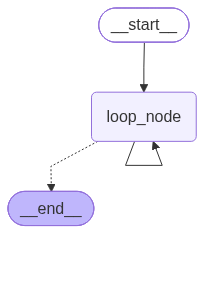

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.errors import GraphRecursionError
from langchain_core.runnables import RunnableConfig

from loguru import logger

class EmptyState(TypedDict):
    pass

def loop_node(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("loop_node, cur_step: {}", cur_step)

builder = StateGraph(state_schema=EmptyState)
builder.add_node("loop_node", loop_node)
builder.add_edge(START, "loop_node")
builder.add_edge("loop_node", "loop_node")

graph = builder.compile()
try:
    graph.invoke({}, config={"recursion_limit": 10})
except GraphRecursionError as e:
    logger.info("超步数量达到最大限制，抛出异常: {}", e)

from IPython.display import display
display(graph)